In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [3]:
# 步骤一: 加载数据集
# 1.1 利用Pandas库read_csv函数读取'Stock_Exchange.csv'文件至DataFrame类型数据data
data = pd.read_csv('Stock_Exchange.csv')
# 1.2 使用to_datetime函数将DateFrame数据中的'Date'列由字符串形式转为日期时间对象
data['Date'] = pd.to_datetime(data['Date'])#此处请编写代码
# 1.3 使用set_index函数将'Date'设为索引值
data.set_index('Date', inplace=True) #此处请编写代码

In [4]:
# 步骤二: 数据预处理及特征工程
# 2.1 提取时间特征（'Date'中的 year、month、day、dayofweek、dayofyear 信息），
#     收盘价变化率（'Close'列的 pct_change 信息）、成交量变化率（'Volume'列的 pct_change 信息），
#     以及当日收盘价（'Close'）作为输入特征 X；
#     以“下一交易日收盘价”作为预测目标 Target
data['Year'] = data.index.year
data['Month'] = data.index.month
data['Day'] = data.index.day
data['Dayofweek'] = data.index.dayofweek
data['Dayofyear'] = data.index.dayofyear
data['Pct_change'] = data['Close'].pct_change()
data['Volume_change'] = data['Volume'].pct_change()
data['Target'] = data['Close'].shift(-1) #此处请编写代码

# 2.2 使用 dropna 删除因 pct_change 和 shift 产生的缺失值
data.dropna(inplace=True)

# 2.3 从 data 中提取 'Year', 'Month', 'Day', 'Dayofweek', 'Dayofyear',
#     'Pct_change', 'Volume_change', 'Close' 作为特征数据 X；
#     从 data 中提取 'Target' 作为标签 y
feature_columns = [
    'Year', 'Month', 'Day', 'Dayofweek', 'Dayofyear',
    'Pct_change', 'Volume_change', 'Close'
]
X = data[feature_columns]
y = data['Target']

print(X)
print(y)

            Year  Month  Day  Dayofweek  Dayofyear  Pct_change  Volume_change  \
Date                                                                            
1986-03-14  1986      3   14          4         73    0.035712      -0.701334   
1986-03-17  1986      3   17          0         76    0.017250      -0.567850   
1986-03-18  1986      3   18          1         77   -0.025432      -0.491133   
1986-03-19  1986      3   19          2         78   -0.017390      -0.293243   
1986-03-20  1986      3   20          3         79   -0.026547       0.220084   
...          ...    ...  ...        ...        ...         ...            ...   
2024-12-23  2024     12   23          0        358   -0.003092      -0.701970   
2024-12-24  2024     12   24          1        359    0.009374      -0.625924   
2024-12-26  2024     12   26          3        361   -0.002777       0.143723   
2024-12-27  2024     12   27          4        362   -0.017302       1.211040   
2024-12-30  2024     12   30

In [5]:
# 步骤三: 数据集划分
# 3.1 选取80%数据作为训练数据，剩下20%数据作为测试数据
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)  #此处请编写代码
# 3.2 使用sklearn库中的StandarScaler对X_train和X_test进行归一化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) #此处请编写代码

In [6]:
# 步骤四：线性回归模型训练
# 使用LinearRegression进行线性回归模型训练
model = LinearRegression() #此处请编写代码
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
# 步骤五：模型测试与性能评估
# 5.1 根据训练好的模型对输入的训练数据和测试数据计算预测值
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# 5.2 利用mean_squared_error、r2_score函数分别计算训练数据和测试数据上的mse, rmse和r2指标
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

C:\Users\30338\AppData\Local\Temp\ipykernel_20344\1204390727.py:22: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\30338\AppData\Local\Temp\ipykernel_20344\1204390727.py:22: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\30338\AppData\Local\Temp\ipykernel_20344\1204390727.py:22: UserWarning: Glyph 32929 (\N{CJK UNIFIED IDEOGRAPH-80A1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\30338\AppData\Local\Temp\ipykernel_20344\1204390727.py:22: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\30338\AppData\Local\Temp\ipykernel_20344\1204390727.py:22: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\30338\AppData\Local\Temp\ipykernel_20344\1204390727.py:22: UserWarning: Glyph 32451 (\

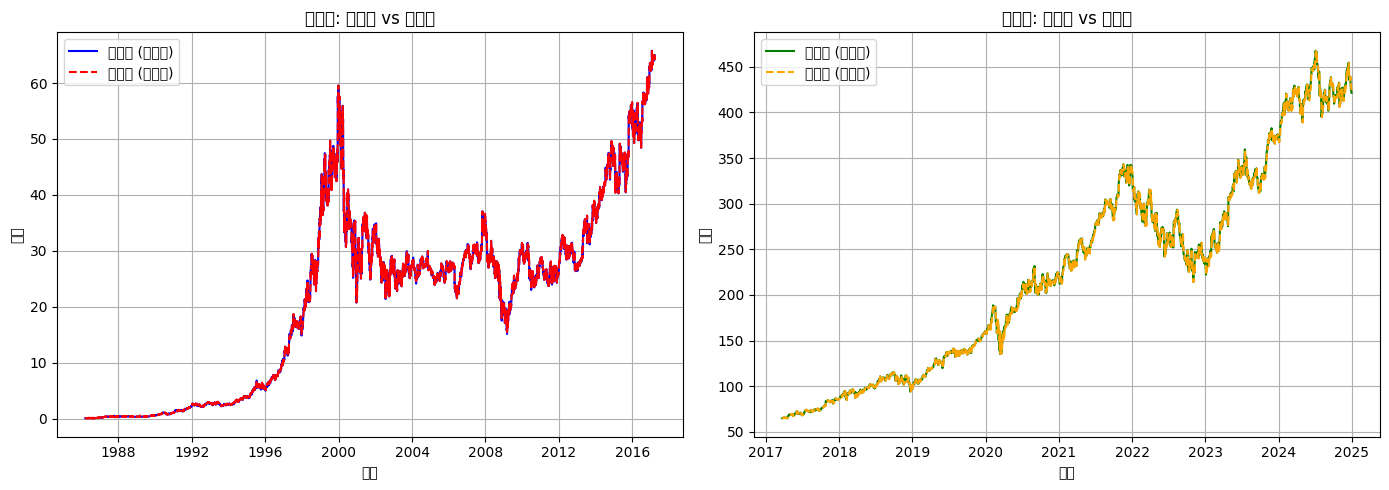

In [8]:
# 步骤六：结果可视化
# 6.1 利用plt函数可视化训练数据上的模型预测值和真实对比图，其中横轴是时间('Date')，纵轴是预测的股价
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(y_train.index, y_train, label='真实值 (训练集)', color='blue')
plt.plot(y_train.index, y_train_pred, label='预测值 (训练集)', color='red', linestyle='--')
plt.title('训练集: 真实值 vs 预测值')
plt.xlabel('时间')
plt.ylabel('股价')
plt.legend()
plt.grid(True)
# 6.2 利用plt函数可视化测试数据上的模型预测值和真实对比图，其中横轴是时间('Date')，纵轴是预测的股价
plt.subplot(1, 2, 2)
plt.plot(y_test.index, y_test, label='真实值 (测试集)', color='green')
plt.plot(y_test.index, y_test_pred, label='预测值 (测试集)', color='orange', linestyle='--')
plt.title('测试集: 真实值 vs 预测值')
plt.xlabel('时间')
plt.ylabel('股价')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()